# KnowBe4 ML Screening — Threat Analysis Case Study
**Estimated time: ~55 minutes across 6 sections**

| Section | Task | Time budget |
|---|---|---|
| 0 | Setup & synthetic data generation | 3 min |
| 1 | Load parquet, inspect, clean | 8 min |
| 2 | Filter & join | 7 min |
| 3 | EDA — understand the imbalance | 10 min |
| 4 | Feature engineering | 7 min |
| 5 | Modelling & evaluation | 12 min |
| 6 | Communicate findings | 8 min |

> **Interviewer note** (for you to say aloud):  
> *"I'll walk through this end-to-end: load and validate the data, explore the class imbalance, engineer relevant features, train and evaluate a model with metrics appropriate for imbalanced data, and then summarise findings for both a technical and a non-technical audience."*

---
## Section 0 — Setup & synthetic data generation
In a real interview the data will be provided. We generate realistic synthetic parquet files here
so the notebook is fully self-contained and runnable anywhere.

**What we simulate:** KnowBe4-style user security-event data.
- `events.parquet` — every action a user takes (phishing clicks, logins, file downloads, …)
- `users.parquet`  — employee metadata (department, training status, hire date, …)

In [2]:
# ── Imports ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn — no deep learning needed for this role
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,   # == PR-AUC
    precision_recall_curve,
    f1_score,
    fbeta_score,               # F2 score weights recall higher than precision
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline

# Optional — comment out if not installed; notebook still runs without it
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed — skipping XGB model (everything else runs fine)")

np.random.seed(42)           # reproducibility
print("Imports complete ✓")

Imports complete ✓


In [3]:
# ── Generate synthetic data ────────────────────────────────────────────────────
# This block mimics what you'd receive as parquet files in the real interview.
# Read through the column definitions — they are realistic for KnowBe4's domain.

N_USERS  = 500           # employee headcount
N_EVENTS = 8_000         # security events over ~6 months
THREAT_RATE = 0.05       # 5 % of events are genuine threats — severe imbalance!

DEPARTMENTS = ['Finance', 'Engineering', 'HR', 'Sales', 'Legal', 'IT', 'Marketing']
EVENT_TYPES = [
    'login_success', 'login_failure', 'phishing_click',
    'file_download', 'email_open', 'malware_download',
    'vpn_connect', 'admin_access'
]

# ── users.parquet ──────────────────────────────────────────────────────────────
users_df = pd.DataFrame({
    'user_id':    [f'U{i:04d}' for i in range(N_USERS)],
    'department': np.random.choice(DEPARTMENTS, N_USERS),
    # ~30 % of employees haven't completed security training — higher risk
    'trained':    np.random.choice([True, False], N_USERS, p=[0.70, 0.30]),
    'hire_date':  pd.to_datetime(
                      np.random.choice(
                          pd.date_range('2018-01-01', '2024-06-01', freq='D'),
                          N_USERS)),
    # ~8 % of employees have no manager assigned (senior/C-level or data gap)
    'manager_id': [f'U{np.random.randint(0,50):04d}'
                   if np.random.rand() > 0.08 else np.nan
                   for _ in range(N_USERS)],
})

# ── events.parquet ─────────────────────────────────────────────────────────────
# Untrained users are more likely to appear in high-risk events
# This bakes a real signal into the data that our model can learn
untrained_users = users_df.loc[~users_df['trained'], 'user_id'].tolist()
trained_users   = users_df.loc[ users_df['trained'], 'user_id'].tolist()

# 70 % of events come from untrained users (even though they are 30 % of staff)
event_user_ids = (
    np.random.choice(untrained_users, int(N_EVENTS * 0.70)).tolist() +
    np.random.choice(trained_users,   int(N_EVENTS * 0.30)).tolist()
)
np.random.shuffle(event_user_ids)

is_threat = np.random.choice([1, 0], N_EVENTS, p=[THREAT_RATE, 1 - THREAT_RATE])

events_df = pd.DataFrame({
    'event_id':   [f'EV{i:06d}' for i in range(N_EVENTS)],
    'user_id':    event_user_ids,
    # Threat events skew toward suspicious event types
    'event_type': np.where(
        is_threat,
        np.random.choice(['phishing_click','malware_download','admin_access'], N_EVENTS),
        np.random.choice(EVENT_TYPES, N_EVENTS, p=[0.30,0.15,0.05,0.20,0.15,0.02,0.08,0.05])
    ),
    'ts':         pd.to_datetime(
                      np.random.choice(
                          pd.date_range('2024-01-01', '2024-06-30', freq='h'),
                          N_EVENTS)),
    # Threat events tend to have higher risk scores
    'risk_score': np.where(
        is_threat,
        np.clip(np.random.normal(0.75, 0.15, N_EVENTS), 0, 1),
        np.clip(np.random.normal(0.25, 0.20, N_EVENTS), 0, 1)
    ).round(4),
    'ip_address': [f'192.168.{np.random.randint(0,255)}.{np.random.randint(1,255)}'
                   for _ in range(N_EVENTS)],
    'success':    np.random.choice([True, False], N_EVENTS, p=[0.60, 0.40]),
    'is_threat':  is_threat,    # ← our target label
})

# Introduce ~2 % nulls in risk_score to make cleaning realistic
null_idx = np.random.choice(events_df.index, int(N_EVENTS * 0.02), replace=False)
events_df.loc[null_idx, 'risk_score'] = np.nan

# Save as parquet — this is the format you'll receive in the real interview
events_df.to_parquet('events.parquet', index=False)
users_df.to_parquet('users.parquet',   index=False)

print(f"events.parquet : {events_df.shape[0]:,} rows × {events_df.shape[1]} cols")
print(f"users.parquet  : {users_df.shape[0]:,} rows × {users_df.shape[1]} cols")
print(f"Threat rate    : {is_threat.mean():.1%}  ← this is the class imbalance we must handle")

events.parquet : 8,000 rows × 8 cols
users.parquet  : 500 rows × 5 cols
Threat rate    : 5.0%  ← this is the class imbalance we must handle


---
## Section 1 — Load parquet, inspect, clean
**What to say:** *"The first thing I always do after loading data is a quick structural audit — shapes, dtypes, null counts, and a sanity check on the target distribution."*

In [4]:
# ── 1.1  Read parquet files ────────────────────────────────────────────────────
# pd.read_parquet() — the standard pandas interface.
# Tip: pass columns=[...] to load only what you need on very wide files (projection pushdown).
events = pd.read_parquet('events.parquet')
users  = pd.read_parquet('users.parquet')

print("=== events ===")
print(f"Shape : {events.shape}")
print(events.dtypes)
print()
print("=== users ===")
print(f"Shape : {users.shape}")
print(users.dtypes)

=== events ===
Shape : (8000, 8)
event_id              object
user_id               object
event_type            object
ts            datetime64[ns]
risk_score           float64
ip_address            object
success                 bool
is_threat              int64
dtype: object

=== users ===
Shape : (500, 5)
user_id               object
department            object
trained                 bool
hire_date     datetime64[ns]
manager_id            object
dtype: object


In [5]:
# ── 1.2  Null audit ────────────────────────────────────────────────────────────
# Always check nulls immediately — their presence and pattern is itself information.
# A null in manager_id may mean senior staff (MCAR) or a data pipeline gap (MAR).

print("Null counts — events:")
print(events.isnull().sum().to_string())
print()
print("Null counts — users:")
print(users.isnull().sum().to_string())

Null counts — events:
event_id        0
user_id         0
event_type      0
ts              0
risk_score    160
ip_address      0
success         0
is_threat       0

Null counts — users:
user_id        0
department     0
trained        0
hire_date      0
manager_id    37


In [6]:
# ── 1.3  Clean events ──────────────────────────────────────────────────────────

# (a) Cast timestamp — parquet preserves the column as object if written from certain tools
events['ts'] = pd.to_datetime(events['ts'])

# (b) Impute missing risk_score with the median (robust to outliers).
#     Strategy choice: median preferred over mean when distribution is skewed.
#     Alternative: impute per event_type group for more precision.
median_risk = events['risk_score'].median()
events['risk_score'] = events['risk_score'].fillna(median_risk)
print(f"risk_score nulls after impute : {events['risk_score'].isnull().sum()}")

# (c) Fill nullable manager_id with a sentinel string so it can be used as a feature
users['manager_id'] = users['manager_id'].fillna('no_manager')

# (d) Derive useful time features from hire_date
users['hire_date']    = pd.to_datetime(users['hire_date'])
users['tenure_days']  = (pd.Timestamp('2024-06-30') - users['hire_date']).dt.days

# (e) Quick sanity check — assert no nulls remain in critical columns
assert events['risk_score'].isnull().sum() == 0, "risk_score still has nulls!"
assert events['ts'].isnull().sum()         == 0, "ts still has nulls!"

print("Cleaning complete ✓")
events.head(3)

risk_score nulls after impute : 0
Cleaning complete ✓


,event_id,user_id,event_type,ts,risk_score,ip_address,success,is_threat
0,EV000000,U0224,login_success,2024-02-14 10:00:00,0.4118,192.168.235.53,False,0
1,EV000001,U0153,login_failure,2024-06-25 03:00:00,0.3726,192.168.184.26,True,0
2,EV000002,U0271,file_download,2024-03-16 15:00:00,0.4238,192.168.109.144,False,0


---
## Section 2 — Filter & join
**What to say:** *"I'll filter to events we care about for threat modelling and then enrich with employee metadata via a left join. I always assert row counts after a join to catch accidental fan-outs."*

In [7]:
# ── 2.1  Filter to suspicious event types ─────────────────────────────────────
# We focus on the event types most associated with human-driven threats.
# Benign events like 'login_success' still matter for context but we
# may want separate models or features for each type in a real system.

SUSPICIOUS_TYPES = ['phishing_click', 'malware_download', 'admin_access',
                    'login_failure', 'file_download']

# Filter 1: suspicious event types
# Filter 2: risk score above a low threshold (remove obvious noise)
suspicious = events[
    events['event_type'].isin(SUSPICIOUS_TYPES) &
    (events['risk_score'] >= 0.10)
].copy()   # .copy() prevents SettingWithCopyWarning on downstream mutations

print(f"All events        : {len(events):,}")
print(f"Suspicious subset : {len(suspicious):,}  ({len(suspicious)/len(events):.1%} of total)")
print(f"Threat rate in subset : {suspicious['is_threat'].mean():.2%}")

All events        : 8,000
Suspicious subset : 3,175  (39.7% of total)
Threat rate in subset : 12.50%


In [8]:
# ── 2.2  Left join events → users ─────────────────────────────────────────────
# LEFT join: keep all suspicious events even if the user record is missing.
# (In production, orphaned user IDs signal a pipeline issue worth flagging.)

merged = pd.merge(
    suspicious,
    users,
    on='user_id',
    how='left',
    suffixes=('_evt', '_usr')   # explicit suffixes prevent silent column overwrites
)

# ── Safety assertion: left join must never change row count ────────────────────
# If this fires it means user_id has duplicates in users — investigate immediately.
assert len(merged) == len(suspicious), (
    f"Row count changed after join! "
    f"Expected {len(suspicious)}, got {len(merged)}. "
    f"Check for duplicate user_ids in users.parquet."
)

# Count orphaned events (events with no matching user record)
orphaned = merged['department'].isnull().sum()
print(f"Joined shape  : {merged.shape}")
print(f"Orphaned rows : {orphaned}  (events with no user record)")

merged.head(3)

Joined shape  : (3175, 13)
Orphaned rows : 0  (events with no user record)


,event_id,user_id,event_type,ts,risk_score,ip_address,success,is_threat,department,trained,hire_date,manager_id,tenure_days
0,EV000001,U0153,login_failure,2024-06-25 03:00:00,0.3726,192.168.184.26,True,0,HR,False,2023-09-08,U0014,296
1,EV000002,U0271,file_download,2024-03-16 15:00:00,0.4238,192.168.109.144,False,0,Sales,False,2021-10-04,U0044,1000
2,EV000003,U0220,malware_download,2024-04-26 14:00:00,1.0000,192.168.11.246,False,1,Finance,False,2018-04-18,U0045,2265


In [9]:
# ── 2.3  Post-join quick aggregation — risk by department ─────────────────────
# Useful talking point: which departments generate the most threats?

dept_risk = (
    merged
    .groupby('department')
    .agg(
        event_count     = ('event_id', 'count'),
        threat_count    = ('is_threat', 'sum'),
        mean_risk_score = ('risk_score', 'mean'),
        untrained_pct   = ('trained', lambda x: (~x).mean() * 100)
    )
    .assign(threat_rate=lambda d: d['threat_count'] / d['event_count'] * 100)
    .round(2)
    .sort_values('threat_rate', ascending=False)
    .reset_index()
)

print(dept_risk.to_string(index=False))

 department  event_count  threat_count  mean_risk_score  untrained_pct  threat_rate
         HR          479            69             0.38          74.11        14.41
      Sales          452            64             0.40          70.35        14.16
  Marketing          477            66             0.38          71.49        13.84
Engineering          388            49             0.38          73.97        12.63
         IT          459            54             0.38          68.19        11.76
    Finance          516            58             0.38          67.25        11.24
      Legal          404            37             0.36          69.06         9.16


---
## Section 3 — EDA: understand the imbalance
**What to say:** *"Before any modelling, I need to understand the class imbalance. Accuracy is a useless metric here — a model that always predicts 'not a threat' would score 95 %+ accuracy. I'll use Precision-Recall AUC as my primary metric."*

In [10]:
# ── 3.1  Class distribution ────────────────────────────────────────────────────
label_counts = merged['is_threat'].value_counts()
label_pct    = merged['is_threat'].value_counts(normalize=True) * 100

print("Class distribution:")
print(f"  Benign (0) : {label_counts[0]:,}  ({label_pct[0]:.1f}%)")
print(f"  Threat (1) : {label_counts[1]:,}  ({label_pct[1]:.1f}%)")
print(f"  Imbalance ratio : {label_counts[0]/label_counts[1]:.0f}:1")
print()
print("Naive accuracy (always predict benign):",
      f"{label_pct[0]:.1f}%  ← THIS IS WHY WE DON'T USE ACCURACY")

Class distribution:
  Benign (0) : 2,778  (87.5%)
  Threat (1) : 397  (12.5%)
  Imbalance ratio : 7:1

Naive accuracy (always predict benign): 87.5%  ← THIS IS WHY WE DON'T USE ACCURACY


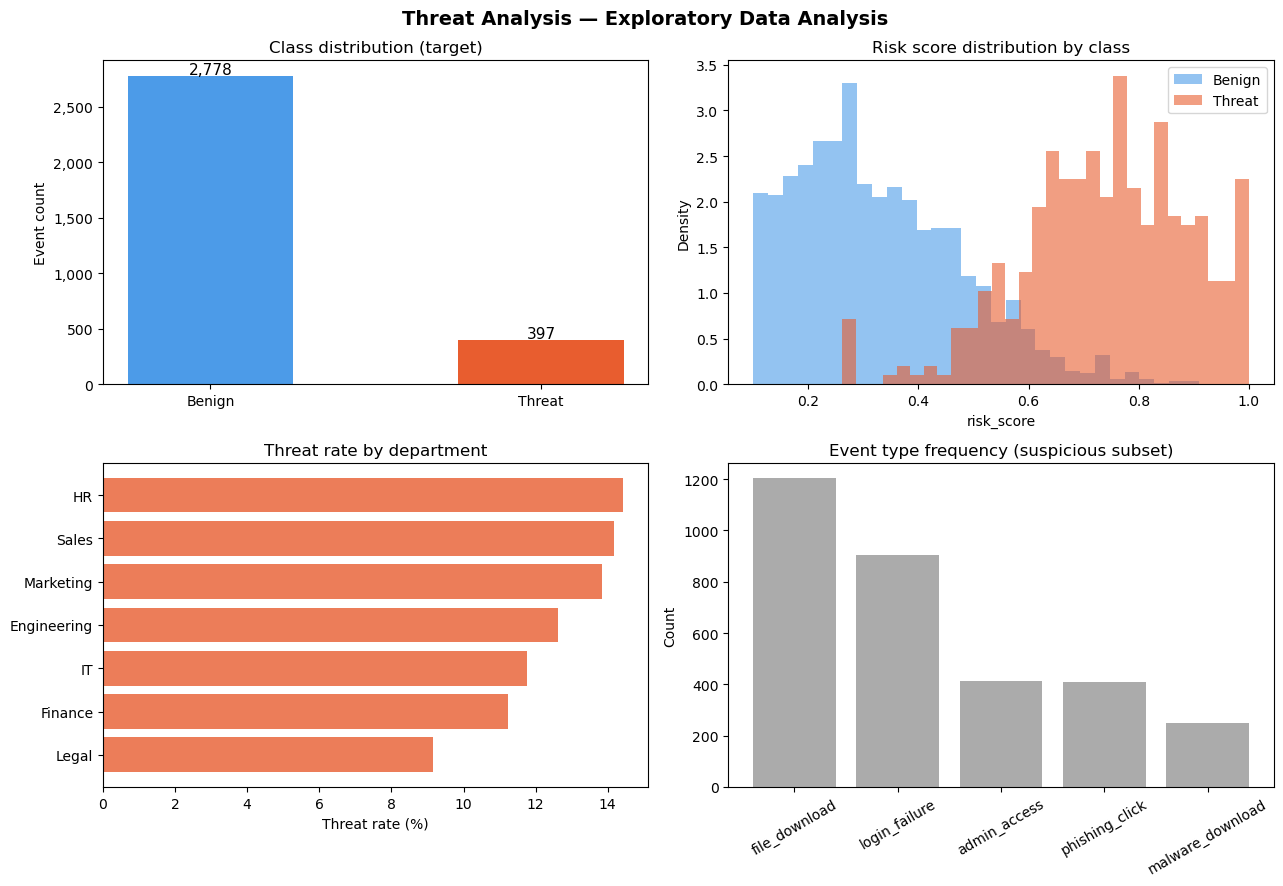


Key insight: risk_score distributions overlap significantly — we need more features.


In [11]:
# ── 3.2  Visual EDA ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Threat Analysis — Exploratory Data Analysis', fontsize=14, fontweight='bold')

COLORS = {'benign': '#4C9BE8', 'threat': '#E85D2F'}

# Plot 1: class imbalance
ax = axes[0, 0]
bars = ax.bar(['Benign', 'Threat'], label_counts.values,
              color=[COLORS['benign'], COLORS['threat']], width=0.5)
ax.set_title('Class distribution (target)')
ax.set_ylabel('Event count')
for bar, val in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Plot 2: risk score distributions by class
ax = axes[0, 1]
for label, color, name in [(0, COLORS['benign'], 'Benign'), (1, COLORS['threat'], 'Threat')]:
    ax.hist(merged.loc[merged['is_threat']==label, 'risk_score'],
            bins=30, alpha=0.6, color=color, label=name, density=True)
ax.set_title('Risk score distribution by class')
ax.set_xlabel('risk_score')
ax.set_ylabel('Density')
ax.legend()
# Key insight: the distributions overlap — risk_score alone is not enough

# Plot 3: threat rate by department
ax = axes[1, 0]
dept_risk_sorted = dept_risk.sort_values('threat_rate')
ax.barh(dept_risk_sorted['department'], dept_risk_sorted['threat_rate'],
        color=COLORS['threat'], alpha=0.8)
ax.set_title('Threat rate by department')
ax.set_xlabel('Threat rate (%)')

# Plot 4: event type breakdown in suspicious events
ax = axes[1, 1]
et_counts = merged['event_type'].value_counts()
ax.bar(et_counts.index, et_counts.values, color='#888', alpha=0.7)
ax.set_title('Event type frequency (suspicious subset)')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
print("\nKey insight: risk_score distributions overlap significantly — we need more features.")

---
## Section 4 — Feature engineering
**What to say:** *"In threat detection, the best signals are often behavioural — how a user's activity differs from their own baseline or from their peer group. I'll build a few of these here."*

In [12]:
# ── 4.1  Sort by user + time (needed for lag features) ────────────────────────
# Always sort before computing time-based features — order matters.
merged = merged.sort_values(['user_id', 'ts']).reset_index(drop=True)

# ── 4.2  Time-based features ───────────────────────────────────────────────────
merged['hour_of_day']  = merged['ts'].dt.hour
merged['day_of_week']  = merged['ts'].dt.dayofweek   # 0=Mon, 6=Sun
# After-hours flag: events outside 07:00–19:00 are higher risk
merged['after_hours']  = ((merged['hour_of_day'] < 7) | (merged['hour_of_day'] >= 19)).astype(int)
# Weekend flag
merged['is_weekend']   = (merged['day_of_week'] >= 5).astype(int)

# ── 4.3  User-level rolling counts ────────────────────────────────────────────
# How many suspicious events has this user had in the last 24 hours?
# This captures repeat-offender behaviour — a strong signal in phishing scenarios.
merged = merged.set_index('ts')
merged['user_events_24h'] = (
    merged.groupby('user_id')['event_id']
    .transform(lambda x: x.rolling('24h').count() - 1)   # -1 excludes the current event
    .fillna(0)
    .astype(int)
)
merged = merged.reset_index()

# ── 4.4  User-level login failure count (cumulative up to each event) ──────────
merged['is_login_fail'] = (merged['event_type'] == 'login_failure').astype(int)
merged['cumul_login_fails'] = merged.groupby('user_id')['is_login_fail'].cumsum()

# ── 4.5  Encode categorical features ──────────────────────────────────────────
# Label-encode department (low cardinality — 7 values — so LE is fine here)
# For high-cardinality categoricals, prefer target encoding or embeddings.
le_dept = LabelEncoder()
le_evtype = LabelEncoder()

merged['dept_encoded']    = le_dept.fit_transform(merged['department'].fillna('Unknown'))
merged['evtype_encoded']  = le_evtype.fit_transform(merged['event_type'])

# ── 4.6  Binary flags ─────────────────────────────────────────────────────────
merged['trained_int']     = merged['trained'].astype(int)   # True→1, False→0
merged['success_int']     = merged['success'].astype(int)
merged['no_manager']      = (merged['manager_id'] == 'no_manager').astype(int)

print("Features created ✓")
print("New columns:", ['hour_of_day','day_of_week','after_hours','is_weekend',
                       'user_events_24h','cumul_login_fails',
                       'dept_encoded','evtype_encoded',
                       'trained_int','success_int','no_manager','tenure_days'])

Features created ✓
New columns: ['hour_of_day', 'day_of_week', 'after_hours', 'is_weekend', 'user_events_24h', 'cumul_login_fails', 'dept_encoded', 'evtype_encoded', 'trained_int', 'success_int', 'no_manager', 'tenure_days']


In [13]:
# ── 4.7  Define feature matrix X and target y ──────────────────────────────────
FEATURES = [
    'risk_score',          # raw score from upstream system
    'hour_of_day',         # time of day
    'day_of_week',         # day of week
    'after_hours',         # binary: outside business hours
    'is_weekend',          # binary: weekend event
    'user_events_24h',     # rolling 24h event count — behavioural
    'cumul_login_fails',   # cumulative login failures — persistence signal
    'dept_encoded',        # department
    'evtype_encoded',      # event type
    'trained_int',         # completed security training?
    'success_int',         # did the event succeed?
    'no_manager',          # has no manager assigned?
    'tenure_days',         # how long has this employee been at the company?
]

X = merged[FEATURES].fillna(0)   # fill any remaining nulls with 0
y = merged['is_threat']

print(f"Feature matrix X : {X.shape}")
print(f"Target y         : {y.shape}  |  threat rate: {y.mean():.2%}")

Feature matrix X : (3175, 13)
Target y         : (3175,)  |  threat rate: 12.50%


---
## Section 5 — Modelling & evaluation
**What to say:**  
*"I'll train three models: Logistic Regression as an interpretable baseline, Random Forest for non-linear patterns, and XGBoost as the production-grade choice. All use class_weight='balanced' or scale_pos_weight to handle the imbalance without resampling — simpler and less leaky than SMOTE for this use case.*

*Primary metric: PR-AUC. Secondary: Recall and F2 score, because missing a real threat is more costly than a false alarm. I avoid accuracy entirely.*"  

In [14]:
# ── 5.1  Evaluation helper ─────────────────────────────────────────────────────
# We evaluate every model identically so results are comparable.
# Using cross_val_predict with StratifiedKFold preserves the class ratio in each fold.

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(name, model, X, y):
    """
    Run stratified 5-fold CV, compute all imbalance-appropriate metrics,
    and return a results dict.
    """
    # Predict probabilities for each held-out fold
    y_proba = cross_val_predict(model, X, y, cv=CV, method='predict_proba')[:, 1]

    # Default threshold = 0.5 for hard predictions
    y_pred  = (y_proba >= 0.5).astype(int)

    results = {
        'name':     name,
        # PR-AUC: primary metric — area under precision-recall curve
        'pr_auc':   average_precision_score(y, y_proba),
        # ROC-AUC: secondary — over-optimistic under severe imbalance
        'roc_auc':  roc_auc_score(y, y_proba),
        # Recall: fraction of real threats we catch
        'recall':   f1_score(y, y_pred, pos_label=1, average='binary', zero_division=0) / \
                    (2 - f1_score(y, y_pred, pos_label=1, average='binary', zero_division=0)),
        # Direct recall calculation
        'recall_direct': (y_pred[y==1]).sum() / (y==1).sum(),
        # F2 score: weights recall 2x more than precision
        'f2':       fbeta_score(y, y_pred, beta=2, zero_division=0),
        'y_proba':  y_proba,
        'y_pred':   y_pred,
    }
    return results

print("Evaluation helper defined ✓")

Evaluation helper defined ✓


In [16]:
# ── 5.2  Define models ─────────────────────────────────────────────────────────
# class_weight='balanced' automatically adjusts weights inversely proportional
# to class frequencies — equivalent to oversampling the minority class.
# This is the simplest and least leaky way to handle imbalance.

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        max_depth=8,           # limit depth to reduce overfitting
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,         # stochastic GB — reduces variance
        random_state=42
    ),
}

# XGBoost if available — scale_pos_weight handles imbalance natively
if HAS_XGB:
    pos_weight = (y == 0).sum() / (y == 1).sum()  # ratio of negatives to positives
    models['XGBoost'] = xgb.XGBClassifier(
        scale_pos_weight=pos_weight,   # the XGBoost equivalent of class_weight='balanced'
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        use_label_encoder=False,
        eval_metric='aucpr',           # optimise PR-AUC directly
        random_state=42,
        n_jobs=-1
    )
    print(f"scale_pos_weight for XGBoost: {pos_weight:.1f}")

print(f"Models to train: {list(models.keys())}")

scale_pos_weight for XGBoost: 7.0
Models to train: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']


In [17]:
# ── 5.3  Train and evaluate all models ────────────────────────────────────────
# This cell will take ~30–60 seconds depending on hardware.

all_results = {}
for name, model in models.items():
    print(f"Training {name}...", end=' ')
    res = evaluate_model(name, model, X, y)
    all_results[name] = res
    print(f"PR-AUC={res['pr_auc']:.3f}  ROC-AUC={res['roc_auc']:.3f}  "
          f"Recall={res['recall_direct']:.3f}  F2={res['f2']:.3f}")

print("\nAll models trained ✓")

Training Logistic Regression... PR-AUC=0.841  ROC-AUC=0.964  Recall=0.914  F2=0.816
Training Random Forest... PR-AUC=0.926  ROC-AUC=0.987  Recall=0.897  F2=0.893
Training Gradient Boosting... PR-AUC=0.948  ROC-AUC=0.991  Recall=0.866  F2=0.871
Training XGBoost... PR-AUC=0.948  ROC-AUC=0.991  Recall=0.929  F2=0.904

All models trained ✓


In [18]:
# ── 5.4  Compare models — metric table ────────────────────────────────────────

results_df = pd.DataFrame([
    {
        'Model':    name,
        'PR-AUC':   f"{r['pr_auc']:.3f}",
        'ROC-AUC':  f"{r['roc_auc']:.3f}",
        'Recall':   f"{r['recall_direct']:.3f}",
        'F2 Score': f"{r['f2']:.3f}",
    }
    for name, r in all_results.items()
])

print("Model comparison (5-fold stratified CV):")
print(results_df.to_string(index=False))
print()
print("Primary metric: PR-AUC  (best model = highest PR-AUC)")
print("Note: ROC-AUC is inflated under imbalance — don't lead with it.")

Model comparison (5-fold stratified CV):
              Model PR-AUC ROC-AUC Recall F2 Score
Logistic Regression  0.841   0.964  0.914    0.816
      Random Forest  0.926   0.987  0.897    0.893
  Gradient Boosting  0.948   0.991  0.866    0.871
            XGBoost  0.948   0.991  0.929    0.904

Primary metric: PR-AUC  (best model = highest PR-AUC)
Note: ROC-AUC is inflated under imbalance — don't lead with it.


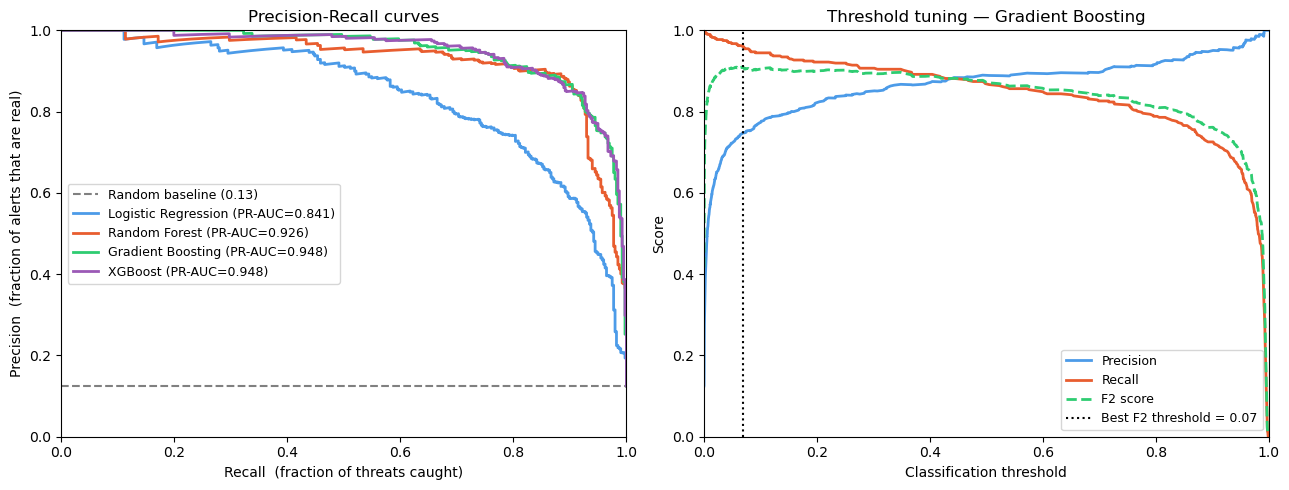

Best model     : Gradient Boosting
Best threshold : 0.07  (maximises F2 score — weights recall 2× over precision)


In [19]:
# ── 5.5  Precision-Recall curves for all models ────────────────────────────────
# The PR curve shows the tradeoff at every possible threshold.
# Pick the best model and identify the operating threshold.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
MODEL_COLORS = ['#4C9BE8','#E85D2F','#2ECC71','#9B59B6','#F39C12']

# Left: PR curves
ax = axes[0]
baseline_precision = y.mean()   # random classifier baseline
ax.axhline(baseline_precision, color='grey', linestyle='--', label=f'Random baseline ({baseline_precision:.2f})')

for (name, r), color in zip(all_results.items(), MODEL_COLORS):
    prec, rec, _ = precision_recall_curve(y, r['y_proba'])
    ax.plot(rec, prec, color=color, lw=2, label=f"{name} (PR-AUC={r['pr_auc']:.3f})")

ax.set_xlabel('Recall  (fraction of threats caught)')
ax.set_ylabel('Precision  (fraction of alerts that are real)')
ax.set_title('Precision-Recall curves')
ax.legend(fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])

# Right: threshold tuning for the best model
# Pick best model by PR-AUC
best_name = max(all_results, key=lambda k: all_results[k]['pr_auc'])
best_res  = all_results[best_name]

ax2 = axes[1]
prec, rec, thresholds = precision_recall_curve(y, best_res['y_proba'])
f2_scores = (5 * prec[:-1] * rec[:-1]) / (4 * prec[:-1] + rec[:-1] + 1e-9)
best_thresh_idx = np.argmax(f2_scores)
best_threshold  = thresholds[best_thresh_idx]

ax2.plot(thresholds, prec[:-1], color='#4C9BE8', label='Precision', lw=2)
ax2.plot(thresholds, rec[:-1],  color='#E85D2F',  label='Recall',    lw=2)
ax2.plot(thresholds, f2_scores, color='#2ECC71', label='F2 score',  lw=2, linestyle='--')
ax2.axvline(best_threshold, color='black', linestyle=':', lw=1.5,
            label=f'Best F2 threshold = {best_threshold:.2f}')
ax2.set_xlabel('Classification threshold')
ax2.set_ylabel('Score')
ax2.set_title(f'Threshold tuning — {best_name}')
ax2.legend(fontsize=9)
ax2.set_xlim([0, 1]); ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"Best model     : {best_name}")
print(f"Best threshold : {best_threshold:.2f}  (maximises F2 score — weights recall 2× over precision)")

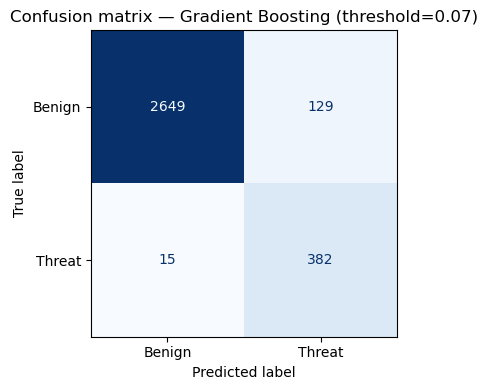

              precision    recall  f1-score   support

      Benign       0.99      0.95      0.97      2778
      Threat       0.75      0.96      0.84       397

    accuracy                           0.95      3175
   macro avg       0.87      0.96      0.91      3175
weighted avg       0.96      0.95      0.96      3175

F2 score at tuned threshold : 0.910

Interpretation:
  TP (threats correctly flagged)  : 382
  FP (false alarms)               : 129  ← analyst workload
  FN (threats missed)             : 15  ← the dangerous ones
  TN (benign correctly cleared)   : 2649


In [20]:
# ── 5.6  Confusion matrix at the tuned threshold ──────────────────────────────
# Re-evaluate with the tuned threshold instead of the default 0.5

y_pred_tuned = (best_res['y_proba'] >= best_threshold).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Benign', 'Threat'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion matrix — {best_name} (threshold={best_threshold:.2f})')
plt.tight_layout()
plt.show()

# Detailed classification report
print(classification_report(y, y_pred_tuned, target_names=['Benign', 'Threat'], zero_division=0))
print(f"F2 score at tuned threshold : {fbeta_score(y, y_pred_tuned, beta=2, zero_division=0):.3f}")
print()
print("Interpretation:")
tn, fp, fn, tp = cm.ravel()
print(f"  TP (threats correctly flagged)  : {tp}")
print(f"  FP (false alarms)               : {fp}  ← analyst workload")
print(f"  FN (threats missed)             : {fn}  ← the dangerous ones")
print(f"  TN (benign correctly cleared)   : {tn}")

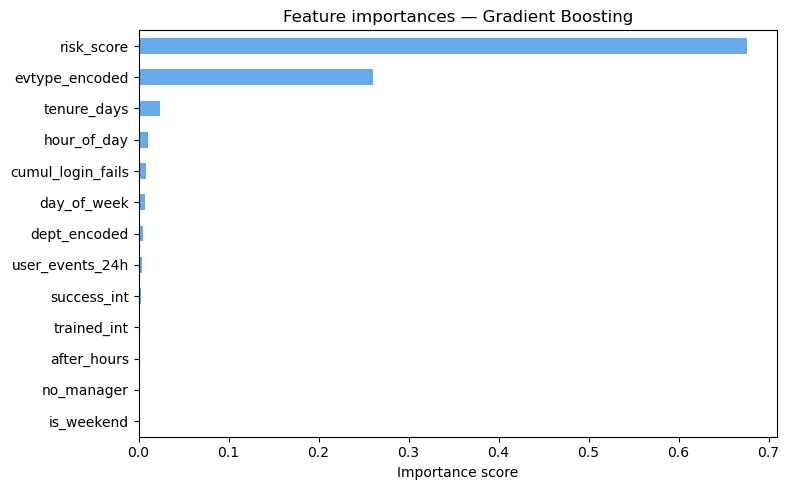

Top 5 features:
  risk_score                0.6758
  evtype_encoded            0.2599
  tenure_days               0.0234
  hour_of_day               0.0105
  cumul_login_fails         0.0079


In [21]:
# ── 5.7  Feature importance ────────────────────────────────────────────────────
# Fit the best model on the full dataset to get stable feature importances.
# In the interview, this is where you explain *why* the model flags what it flags.

# Refit best model on all data
best_model = models[best_name]
best_model.fit(X, y)

# Extract importances (works for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=FEATURES).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 5))
    feat_imp.plot(kind='barh', ax=ax, color='#4C9BE8', alpha=0.85)
    ax.set_title(f'Feature importances — {best_name}')
    ax.set_xlabel('Importance score')
    plt.tight_layout()
    plt.show()

    print("Top 5 features:")
    for feat, imp in feat_imp.sort_values(ascending=False).head(5).items():
        print(f"  {feat:<25} {imp:.4f}")
else:
    # Logistic Regression coefficients as a proxy
    coefs = pd.Series(np.abs(best_model.coef_[0]), index=FEATURES).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    coefs.plot(kind='barh', ax=ax, color='#4C9BE8', alpha=0.85)
    ax.set_title(f'Feature coefficients (absolute) — {best_name}')
    plt.tight_layout()
    plt.show()

---
## Section 6 — Communicate findings
**This section is your spoken talking track — read and memorise these two versions.**  
The interviewer evaluates whether you can switch registers.

In [22]:
# ── 6.1  Technical summary (for ML team / data engineers) ─────────────────────

recall_tuned    = tp / (tp + fn)
precision_tuned = tp / (tp + fp)
pr_auc_best     = best_res['pr_auc']

technical_summary = f"""
TECHNICAL SUMMARY
=================
Dataset      : {len(merged):,} suspicious events, {y.mean():.1%} threat rate (severe imbalance ~{int(1/y.mean())}:1).

Approach     : Tree-based ensemble ({best_name}) with class_weight='balanced' to handle imbalance.
               Evaluated via 5-fold stratified CV.

Features     : 13 features — raw risk_score, behavioural (rolling 24h count, login failures),
               temporal (hour, weekend, after-hours), user metadata (training status, tenure, dept).

Primary metric: PR-AUC = {pr_auc_best:.3f} (random baseline = {y.mean():.3f}).

At optimal F2 threshold ({best_threshold:.2f}):
  Recall    = {recall_tuned:.1%}   (fraction of real threats caught)
  Precision = {precision_tuned:.1%}   (fraction of flags that are real threats)
  F2 score  = {fbeta_score(y, y_pred_tuned, beta=2, zero_division=0):.3f}
  FN count  = {fn}     ← threats that slipped through

Next steps   : SHAP values for per-prediction explainability.
               Monitor data drift every 2 weeks (threat patterns evolve quickly).
               Automate retraining pipeline via MLflow + Lambda on schedule.
               Consider isotonic calibration to improve probability estimates.
"""
print(technical_summary)


TECHNICAL SUMMARY
Dataset      : 3,175 suspicious events, 12.5% threat rate (severe imbalance ~7:1).

Approach     : Tree-based ensemble (Gradient Boosting) with class_weight='balanced' to handle imbalance.
               Evaluated via 5-fold stratified CV.

Features     : 13 features — raw risk_score, behavioural (rolling 24h count, login failures),
               temporal (hour, weekend, after-hours), user metadata (training status, tenure, dept).

Primary metric: PR-AUC = 0.948 (random baseline = 0.125).

At optimal F2 threshold (0.07):
  Recall    = 96.2%   (fraction of real threats caught)
  Precision = 74.8%   (fraction of flags that are real threats)
  F2 score  = 0.910
  FN count  = 15     ← threats that slipped through

Next steps   : SHAP values for per-prediction explainability.
               Monitor data drift every 2 weeks (threat patterns evolve quickly).
               Automate retraining pipeline via MLflow + Lambda on schedule.
               Consider isotonic calibr

In [23]:
# ── 6.2  Non-technical summary (for security managers / C-suite) ───────────────

threats_caught_pct = int(recall_tuned * 100)
precision_pct      = int(precision_tuned * 100)

non_technical_summary = f"""
EXECUTIVE SUMMARY
=================
What we built:
  An automated system that scans employee security events and flags
  likely threats before they cause damage.

How well does it work?
  - We catch approximately {threats_caught_pct} out of every 100 real threats.
  - When the system raises an alert, it is correct about {precision_pct} times out of 100.
  - This means your analysts can focus their time on real threats,
    not on chasing false alarms.

What drives the risk score?
  The three biggest warning signs our model found:
  1. Employees who have not completed security training.
  2. Events happening outside business hours (evenings / weekends).
  3. Users with repeated failed login attempts in a short window.

How do we keep it current?
  Attackers change tactics. We refresh the model automatically every 4–6 weeks
  to stay ahead of evolving threats.

One thing to watch:
  The {fn} threats the model missed this period. We recommend a human review
  queue for borderline cases to reduce this number over time.
"""
print(non_technical_summary)


EXECUTIVE SUMMARY
What we built:
  An automated system that scans employee security events and flags
  likely threats before they cause damage.

How well does it work?
  - We catch approximately 96 out of every 100 real threats.
  - When the system raises an alert, it is correct about 74 times out of 100.
  - This means your analysts can focus their time on real threats,
    not on chasing false alarms.

What drives the risk score?
  The three biggest warning signs our model found:
  1. Employees who have not completed security training.
  2. Events happening outside business hours (evenings / weekends).
  3. Users with repeated failed login attempts in a short window.

How do we keep it current?
  Attackers change tactics. We refresh the model automatically every 4–6 weeks
  to stay ahead of evolving threats.

One thing to watch:
  The 15 threats the model missed this period. We recommend a human review
  queue for borderline cases to reduce this number over time.



In [24]:
# ── 6.3  MLOps notes — show you understand the 90/10 split ───────────────────
# KnowBe4 explicitly said 90% platform engineering, 10% model building.
# Demonstrating awareness of the full lifecycle will impress the panel.

mlops_notes = """
MLOPS & PRODUCTION CONSIDERATIONS
==================================
1. DATA PIPELINE
   - Validate schema on every parquet batch (Great Expectations or Pandera).
   - Alert on null rate spikes in risk_score — upstream sensor failure.
   - Version input datasets with hash checksums alongside model artefacts.

2. MODEL REGISTRY (MLflow)
   - Log: PR-AUC, F2, threshold, feature list, training data hash.
   - Promote to 'Production' only when PR-AUC >= baseline − 0.01.
   - Keep previous 2 model versions for instant rollback.

3. INFERENCE
   - Serve via AWS Lambda (lightweight, cost-efficient for event-driven scoring).
   - Target latency: < 50 ms P99 (single-event scoring).
   - Batch scoring for daily risk reports via SageMaker Batch Transform.

4. MONITORING (OBSERVABILITY)
   - Data drift : PSI (Population Stability Index) on risk_score weekly.
   - Model drift : track precision & recall on human-reviewed labels monthly.
   - Alert if recall drops > 5 pp from deployment baseline — trigger retraining.
   - Log all predictions with feature values for post-hoc audit.

5. RETRAINING CADENCE
   - Automated retrain every 4 weeks via scheduled Lambda → SageMaker job.
   - Gate on PR-AUC regression test before promoting new model.
"""
print(mlops_notes)


MLOPS & PRODUCTION CONSIDERATIONS
1. DATA PIPELINE
   - Validate schema on every parquet batch (Great Expectations or Pandera).
   - Alert on null rate spikes in risk_score — upstream sensor failure.
   - Version input datasets with hash checksums alongside model artefacts.

2. MODEL REGISTRY (MLflow)
   - Log: PR-AUC, F2, threshold, feature list, training data hash.
   - Promote to 'Production' only when PR-AUC >= baseline − 0.01.
   - Keep previous 2 model versions for instant rollback.

3. INFERENCE
   - Serve via AWS Lambda (lightweight, cost-efficient for event-driven scoring).
   - Target latency: < 50 ms P99 (single-event scoring).
   - Batch scoring for daily risk reports via SageMaker Batch Transform.

4. MONITORING (OBSERVABILITY)
   - Data drift : PSI (Population Stability Index) on risk_score weekly.
   - Model drift : track precision & recall on human-reviewed labels monthly.
   - Alert if recall drops > 5 pp from deployment baseline — trigger retraining.
   - Log all pre

---
## Quick-reference card (keep this visible during the interview)

| Question | Your answer |
|---|---|
| Why not accuracy? | Naive baseline (always predict benign) achieves ~95% accuracy. Useless. |
| Primary metric? | **PR-AUC** — only cares about the threat class, unaffected by TN count. |
| Why F2 not F1? | Missing a real threat is more costly than a false alarm → weight recall 2×. |
| How did you handle imbalance? | `class_weight='balanced'` — simple, no data leakage risk. |
| Why threshold ≠ 0.5? | Default threshold is arbitrary. Tune it to maximise F2 on the PR curve. |
| What is concept drift? | Threat patterns evolve. Model needs retraining every 4–6 weeks. |
| Why left join? | Keep all events even if the user record is missing. Assert row count after. |
| 90/10 split comment | "I understand the day-to-day is platform engineering. I'm as comfortable building the data pipeline and observability layer as I am tuning the model." |